# Exploratoty Data Analysis

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('../data/tcga_simple_train.csv')

In [ ]:
df.head()

,patient_id,text,t
0,TCGA-BP-5195,Date of Recelpt: Clinical Diagnosis & History:...,T1
1,TCGA-D7-8573,"Material: 1) Material: stomach, Method of coll...",T3
2,TCGA-EI-7004,page 1 / 1. copy No. 3. Examination: Histopath...,T4
3,TCGA-EB-A82B,Patient ID: Gross Description: A mass is locat...,T4
4,TCGA-A6-3808,SPECIMEN. Right colon. CLINICAL NOTES. PRE-OP ...,T3


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5158 entries, 0 to 5157
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   patient_id  5158 non-null   str  
 1   text        5158 non-null   str  
 2   t           5158 non-null   str  
dtypes: str(3)
memory usage: 121.0 KB


Valores nulos

In [15]:
print(df.isnull().sum())

patient_id    0
text          0
t             0
dtype: int64


Distribución de clases

In [8]:
print(df['t'].value_counts())

t
T2    1752
T3    1583
T1    1302
T4     521
Name: count, dtype: int64


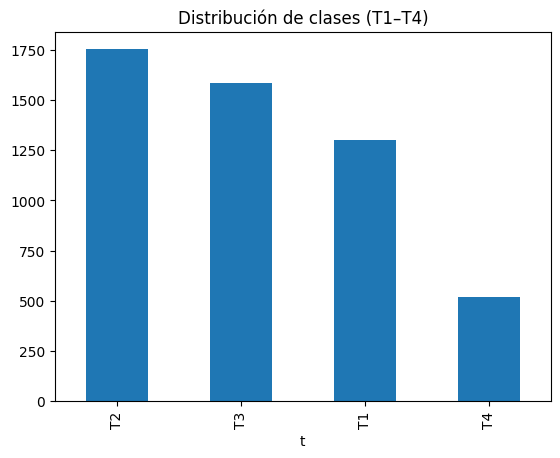

In [19]:
import matplotlib.pyplot as plt

df['t'].value_counts().plot(kind='bar')
plt.title("Distribución de clases (T1–T4)")
plt.show()

Longitud de los textos

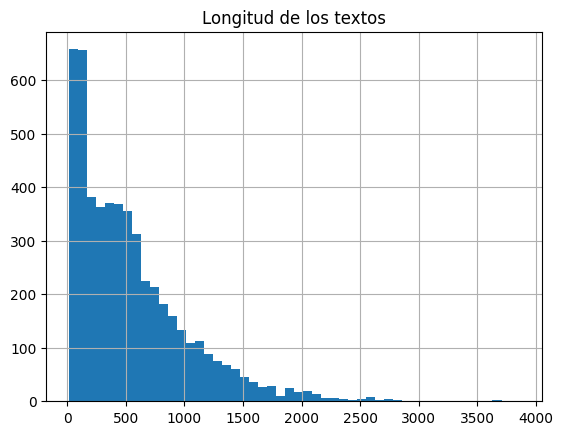

In [20]:
df['text_length'] = df['text'].apply(lambda x: len(x.split()))

df['text_length'].hist(bins=50)
plt.title("Longitud de los textos")
plt.show()

Ejemplos

In [21]:
for i in range(3):
    print("Texto:", df['text'].iloc[i][:500])
    print("Label:", df['t'].iloc[i])
    print("-"*50)

Texto: Date of Recelpt: Clinical Diagnosis & History: Incidental 3 cm left upper pole renal mass. Specimens Submitted: 1: Kidney, Left Upper Pole; Partial Nephrectomy. DIAGNOSIS: 1. Kidney, Left Upper Pole; Partial Nephrectomy: Tumor Type: Renal cell carcinoma - Conventional (clear cell) type. Fuhrman Nuclear Grade: Nuclear grade II/IV. Tumor Size: Greatest diameter is 2.4 cm. Local Invasion (for renal cortical types): Not Identified. Renal Vein Invasion: Not identified. Surgical Margins: Free of tumor
Label: T1
--------------------------------------------------
Texto: Material: 1) Material: stomach, Method of collection: Lesion resection. Histopathological diagnosis: (including test No. G-3155/12): Adenocarcinoma tubuläre ventriculi. G3, pT3, pNO. Tubular adenocarcinoma of the. stomach. Typus intestinalis sec Lauren. Intestinal type Lauren. Macroscopic description: Adenocarcinoma tubuläre G3. Cancerous proliferation reaches the periteneal surface of the stomach. Surgical incision line

Palabras más comunes

In [22]:
from collections import Counter
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

all_words = " ".join(df['text'].apply(clean_text)).split()
common_words = Counter(all_words).most_common(20)

print(common_words)

[('the', 102840), ('of', 76879), ('and', 62393), ('is', 55260), ('cm', 50535), ('x', 49056), ('lymph', 47688), ('a', 45420), ('in', 44277), ('tumor', 39686), ('nodes', 27199), ('with', 26861), ('node', 26081), ('to', 26052), ('margin', 24566), ('tissue', 24166), ('right', 23653), ('specimen', 23508), ('left', 22035), ('for', 20395)]


Palabras por clase

In [23]:
for label in df['t'].unique():
    text = " ".join(df[df['t'] == label]['text'].apply(clean_text))
    words = Counter(text.split()).most_common(10)
    
    print(f"\nClase {label}:")
    print(words)


Clase T1:
[('the', 23816), ('of', 16962), ('is', 13895), ('and', 13763), ('cm', 11734), ('a', 10970), ('x', 10705), ('tumor', 10271), ('in', 9814), ('lymph', 9261)]

Clase T3:
[('the', 34511), ('of', 25079), ('and', 20624), ('is', 17317), ('cm', 16208), ('lymph', 16079), ('x', 15233), ('in', 14542), ('a', 13851), ('tumor', 12426)]

Clase T4:
[('the', 10719), ('of', 8796), ('and', 6925), ('x', 6300), ('is', 5503), ('cm', 5218), ('lymph', 5218), ('a', 4811), ('in', 4554), ('tumor', 4085)]

Clase T2:
[('the', 33794), ('of', 26042), ('and', 21081), ('is', 18545), ('cm', 17375), ('lymph', 17130), ('x', 16818), ('a', 15788), ('in', 15367), ('tumor', 12904)]


Longitud del texto por clase

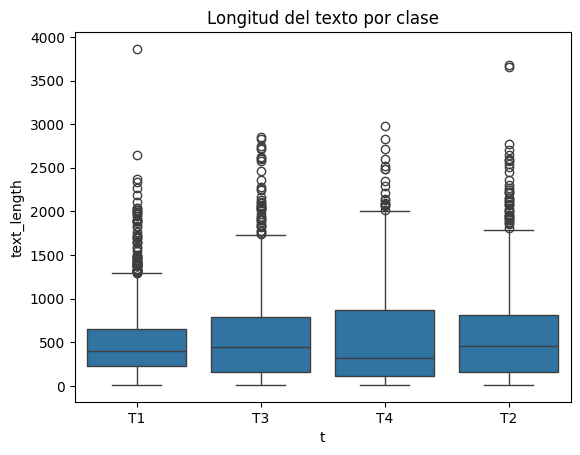

In [25]:
import seaborn as sns

sns.boxplot(x='t', y='text_length', data=df)
plt.title("Longitud del texto por clase")
plt.show()

In [26]:
print("Resumen:")
print(df['t'].value_counts(normalize=True))
print(df['text_length'].describe())

Resumen:
t
T2    0.339667
T3    0.306902
T1    0.252423
T4    0.101008
Name: proportion, dtype: float64
count    5158.000000
mean      546.435440
std       482.666821
min        11.000000
25%       162.000000
50%       430.500000
75%       765.000000
max      3862.000000
Name: text_length, dtype: float64
